In [5]:
import polars as pl

path = r"C:\Users\Aksha\Data-Science-Fundamentals\Anomaly Detection\Data\realAWSCloudwatch\realAWSCloudwatch\ec2_disk_write_bytes_1ef3de.csv"

df = pl.read_csv(path)

column_map = {
    "timestamp": "time",
    "value": "value"
}

df = df.rename(column_map)


df = df.with_columns(pl.col("time").str.strptime(pl.Datetime, 
                                                 format="%Y-%m-%d %H:%M:%S"))
df


time,value
datetime[μs],f64
2014-03-01 17:34:00,0.0
2014-03-01 17:39:00,0.0
2014-03-01 17:44:00,0.0
2014-03-01 17:49:00,0.0
2014-03-01 17:54:00,0.0
…,…
2014-03-18 03:19:00,0.0
2014-03-18 03:24:00,0.0
2014-03-18 03:29:00,0.0


In [6]:
import matplotlib.pyplot as plt
import polars as pl

def plot(
    df: pl.DataFrame,
    x="time",
    y="value",
    anomaly=False,
    figsize=(12, 8),
    **kwargs
):
    # Sort by time (important for time series)
    df = df.sort(x)

    fig, ax = plt.subplots(figsize=figsize)

    x_vals = df[x].to_numpy()
    y_vals = df[y].to_numpy()

    # Confidence band
    if {"upper", "lower"}.issubset(df.columns):
        ax.fill_between(
            x_vals,
            df["lower"].to_numpy(),
            df["upper"].to_numpy(),
            alpha=0.25,
            label="Expected range",
            color="tab:orange",
            zorder=2
        )

    # Expected line
    if "expected" in df.columns:
        ax.plot(
            x_vals,
            df["expected"].to_numpy(),
            linestyle="--",
            label="Expected",
            zorder=3
        )

    # Actual values
    ax.plot(
        x_vals,
        y_vals,
        label="Actual",
        zorder=4,
        color="tab:blue",
        **kwargs
    )

    # Anomaly points
    if anomaly and "anomaly" in df.columns:
        anomaly_df = df.filter(pl.col("anomaly"))

        ax.scatter(
            anomaly_df[x].to_numpy(),
            anomaly_df[y].to_numpy(),
            label="Anomaly",
            marker="o",
            c="tab:red",
            zorder=5
        )

    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.legend()
    plt.show()


In [7]:
from sklearn.ensemble import IsolationForest

values = df.select("value").to_numpy()

model = IsolationForest(
    contamination=0.01,
    random_state=42
)

preds = model.fit_predict(values)

df = df.with_columns(
    (pl.Series(preds) == -1).alias("anomaly")
)

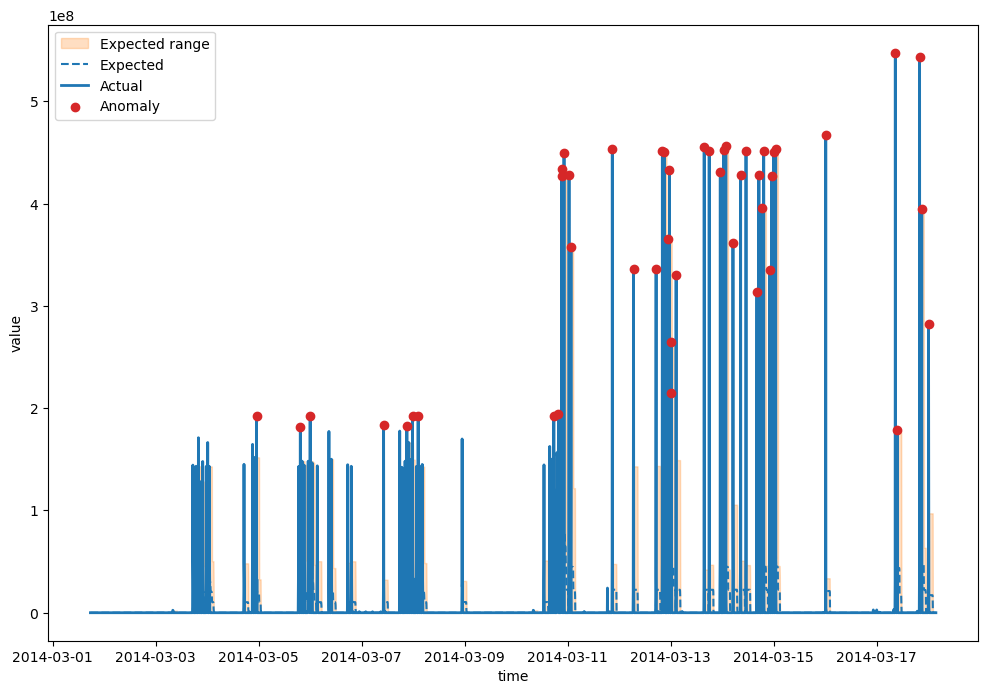

In [9]:
window = 24

df = df.with_columns([
    pl.col("value")
      .rolling_mean(window_size=window, min_samples=1)
      .alias("expected"),

    pl.col("value")
      .rolling_quantile(0.95, window_size=window, min_samples=1)
      .alias("upper"),

    pl.col("value")
      .rolling_quantile(0.05, window_size=window, min_samples=1)
      .alias("lower"),
])


plot(df, x= "time", y = "value", anomaly=True, linewidth=2)